<a href="https://colab.research.google.com/github/Pranav362k05/Clickbait-headline-detection-NLP/blob/main/Clickbait_headline_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 📦 Cell 1 — Install & Setup Kaggle

# **PRANAV KRISHNA Y**

### **Clickbait Headline Detection**

**Task:** Classify news article headlines as clickbait or non-clickbait

**Models:** Logistic Regression, Naive Bayes, SVM

**Evaluation:** Accuracy, Precision, Recall, F1-score

In [68]:
# ============================================================
# CELL 1: Install Kaggle library and set up API credentials
# ============================================================

# Install the Kaggle library so we can download datasets
!pip install kaggle -q

import os

# --- Set your Kaggle credentials as environment variables ---
# The API token format is: KGAT_<long_string>
os.environ['KAGGLE_USERNAME'] = 'pranav362k05'
os.environ['KAGGLE_KEY'] = 'KGAT_792b9ec285edc384d704190df129ad1c'

# Create the ~/.kaggle directory if it doesn't exist
os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)

# Write the kaggle.json file that the Kaggle API needs
import json
kaggle_config = {
    "username": os.environ['KAGGLE_USERNAME'],
    "key": os.environ['KAGGLE_KEY']
}
config_path = os.path.expanduser('~/.kaggle/kaggle.json')
with open(config_path, 'w') as f:
    json.dump(kaggle_config, f)

# Set correct permissions (required by Kaggle)
os.chmod(config_path, 0o600)

print("✅ Kaggle credentials set up successfully!")

✅ Kaggle credentials set up successfully!


📥 Cell 2 — Download & Unzip Dataset

In [69]:
# ============================================================
# CELL 2: Download the Clickbait dataset from Kaggle
# ============================================================

# Download the dataset using Kaggle CLI
# Dataset: amananandrai/clickbait-dataset
!kaggle datasets download -d amananandrai/clickbait-dataset

# Unzip the downloaded file into the current directory
import zipfile

zip_file = 'clickbait-dataset.zip'

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall('clickbait_data')
    print("Files extracted:")
    for name in zip_ref.namelist():
        print("  -", name)

print("\n✅ Dataset downloaded and extracted!")

Dataset URL: https://www.kaggle.com/datasets/amananandrai/clickbait-dataset
License(s): unknown
clickbait-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
Files extracted:
  - clickbait_data.csv

✅ Dataset downloaded and extracted!


 📂 Cell 3 — Load Dataset into Pandas

In [70]:
# ============================================================
# CELL 3: Load the dataset into a Pandas DataFrame
# ============================================================

import pandas as pd
import os

# List all files to find the correct CSV filename
print("Files in clickbait_data folder:")
for f in os.listdir('clickbait_data'):
    print(" -", f)

# Load the CSV file (adjust filename if yours is different)
# Common filenames: 'clickbait_data.csv', 'data.csv'
df = pd.read_csv('clickbait_data/clickbait_data.csv')

# Show first 5 rows
print("\nFirst 5 rows of the dataset:")
print(df.head())

# Show shape (rows x columns)
print(f"\nDataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

# Show how many clickbait vs non-clickbait
print("\nLabel distribution:")
print(df.iloc[:, -1].value_counts())  # Last column is usually the label

Files in clickbait_data folder:
 - clickbait_data.csv

First 5 rows of the dataset:
                                            headline  clickbait
0                                 Should I Get Bings          1
1      Which TV Female Friend Group Do You Belong In          1
2  The New "Star Wars: The Force Awakens" Trailer...          1
3  This Vine Of New York On "Celebrity Big Brothe...          1
4  A Couple Did A Stunning Photo Shoot With Their...          1

Dataset shape: (32000, 2)
Columns: ['headline', 'clickbait']

Label distribution:
clickbait
0    16001
1    15999
Name: count, dtype: int64


🔍 Cell 4 — Explore & Handle Column Names

In [71]:
# ============================================================
# CELL 4: Identify correct column names and clean up
# ============================================================

# Print all column names to understand the structure
print("Column names:", df.columns.tolist())

# ---- AUTO-DETECT headline and label columns ----
# This handles datasets where columns may have different names

headline_col = None
label_col = None

for col in df.columns:
    col_lower = col.lower()
    if any(word in col_lower for word in ['headline', 'title', 'text', 'news']):
        headline_col = col
    if any(word in col_lower for word in ['label', 'class', 'clickbait', 'target']):
        label_col = col

# Fallback: if not found by name, use first and last column
if headline_col is None:
    headline_col = df.columns[0]
if label_col is None:
    label_col = df.columns[-1]

print(f"\n✅ Detected headline column: '{headline_col}'")
print(f"✅ Detected label column: '{label_col}'")

# Rename for convenience
df = df[[headline_col, label_col]].copy()
df.columns = ['headline', 'label']

# Drop any missing values
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"\nCleaned dataset shape: {df.shape}")
print(df['label'].value_counts())
print("\nSample rows:")
print(df.head(5))

Column names: ['headline', 'clickbait']

✅ Detected headline column: 'headline'
✅ Detected label column: 'clickbait'

Cleaned dataset shape: (32000, 2)
label
0    16001
1    15999
Name: count, dtype: int64

Sample rows:
                                            headline  label
0                                 Should I Get Bings      1
1      Which TV Female Friend Group Do You Belong In      1
2  The New "Star Wars: The Force Awakens" Trailer...      1
3  This Vine Of New York On "Celebrity Big Brothe...      1
4  A Couple Did A Stunning Photo Shoot With Their...      1


🧹 Cell 5 — Text Preprocessing

In [72]:
# ============================================================
# CELL 5: Clean and preprocess the headline text
# ============================================================

import re
import string

def clean_text(text):
    """
    Cleans a single headline string.
    Steps:
      1. Convert to lowercase
      2. Remove URLs
      3. Remove punctuation
      4. Remove extra whitespace
    """
    # Step 1: Lowercase
    text = text.lower()

    # Step 2: Remove URLs (e.g. http://...)
    text = re.sub(r'http\S+|www\S+', '', text)

    # Step 3: Remove punctuation (!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~)
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Step 4: Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Apply cleaning to the headline column
df['clean_headline'] = df['headline'].apply(clean_text)

# Show before and after for the first 3 rows
print("Original vs Cleaned Headlines:\n")
for i in range(3):
    print(f"ORIGINAL : {df['headline'][i]}")
    print(f"CLEANED  : {df['clean_headline'][i]}")
    print("-" * 60)

print("\n✅ Text preprocessing complete!")

Original vs Cleaned Headlines:

ORIGINAL : Should I Get Bings
CLEANED  : should i get bings
------------------------------------------------------------
ORIGINAL : Which TV Female Friend Group Do You Belong In
CLEANED  : which tv female friend group do you belong in
------------------------------------------------------------
ORIGINAL : The New "Star Wars: The Force Awakens" Trailer Is Here To Give You Chills
CLEANED  : the new star wars the force awakens trailer is here to give you chills
------------------------------------------------------------

✅ Text preprocessing complete!


✂️ Cell 6 — Train/Test Split

In [73]:
# ============================================================
# CELL 6: Split the data into training and testing sets
# ============================================================

from sklearn.model_selection import train_test_split

# X = features (headlines), y = labels (clickbait/not)
X = df['clean_headline']
y = df['label']

# 80% for training, 20% for testing
# random_state=42 ensures reproducible results
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # keeps label ratio same in train and test
)

print(f"Total samples   : {len(df)}")
print(f"Training samples: {len(X_train)}")
print(f"Testing samples : {len(X_test)}")
print("\n✅ Train/test split done!")

Total samples   : 32000
Training samples: 25600
Testing samples : 6400

✅ Train/test split done!


🔢 Cell 7 — TF-IDF Feature Extraction

In [74]:
# ============================================================
# CELL 7: TF-IDF Feature Extraction
# ============================================================

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    stop_words='english'
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f"Training matrix shape: {X_train_tfidf.shape}")
print(f"Testing matrix shape : {X_test_tfidf.shape}")
print("✅ TF-IDF done!")

Training matrix shape: (25600, 5000)
Testing matrix shape : (6400, 5000)
✅ TF-IDF done!


🤖 Cell 8 — Train Logistic Regression

In [75]:
# ============================================================
# CELL 8: Train Logistic Regression
# ============================================================

from sklearn.linear_model import LogisticRegression

# Safety check — makes sure Cell 7 was run first
try:
    X_train_tfidf
except NameError:
    raise RuntimeError("❌ Please run Cell 7 (TF-IDF) first!")

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_tfidf, y_train)
lr_predictions = lr_model.predict(X_test_tfidf)

print("✅ Logistic Regression trained!")
print(f"Sample predictions : {lr_predictions[:10]}")
print(f"Actual labels      : {y_test.values[:10]}")

✅ Logistic Regression trained!
Sample predictions : [1 0 1 1 1 0 0 0 1 1]
Actual labels      : [1 1 1 1 1 0 0 0 1 1]


🧪 Cell 9 — Train Naive Bayes

In [76]:
# ============================================================
# CELL 9: Train Naive Bayes (for comparison)
# ============================================================

from sklearn.naive_bayes import MultinomialNB

try:
    X_train_tfidf
except NameError:
    raise RuntimeError("❌ Please run Cell 7 (TF-IDF) first!")

nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
nb_predictions = nb_model.predict(X_test_tfidf)

print("✅ Naive Bayes trained!")
print(f"Sample predictions : {nb_predictions[:10]}")
print(f"Actual labels      : {y_test.values[:10]}")

✅ Naive Bayes trained!
Sample predictions : [1 0 1 1 1 0 0 0 1 1]
Actual labels      : [1 1 1 1 1 0 0 0 1 1]


📊 Cell 10 — Evaluate Both Models


  MODEL: Logistic Regression
  Accuracy  : 0.9503  (95.03%)
  Precision : 0.9506
  Recall    : 0.9503
  F1-Score  : 0.9503

  Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95      3200
           1       0.96      0.94      0.95      3200

    accuracy                           0.95      6400
   macro avg       0.95      0.95      0.95      6400
weighted avg       0.95      0.95      0.95      6400



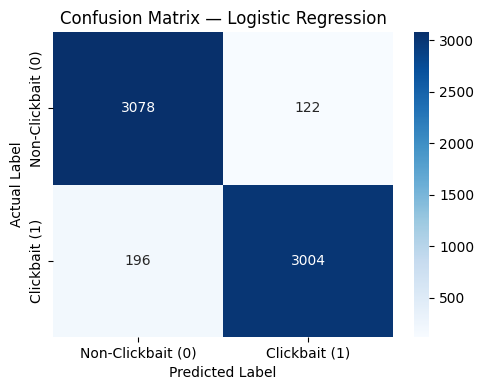


  MODEL: Naive Bayes
  Accuracy  : 0.9541  (95.41%)
  Precision : 0.9541
  Recall    : 0.9541
  F1-Score  : 0.9541

  Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.96      0.95      3200
           1       0.96      0.95      0.95      3200

    accuracy                           0.95      6400
   macro avg       0.95      0.95      0.95      6400
weighted avg       0.95      0.95      0.95      6400



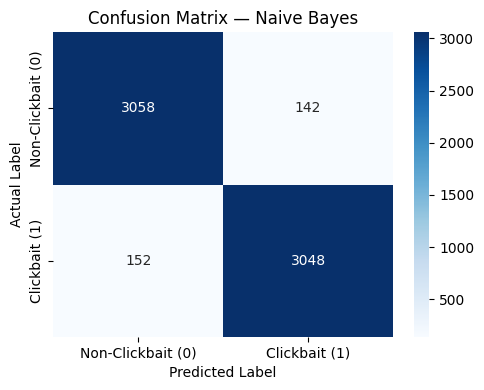

In [77]:
# ============================================================
# CELL 10: Evaluate both models with all metrics
# ============================================================

from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score,
    classification_report, confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns

# Safety check
try:
    lr_predictions
    nb_predictions
except NameError:
    raise RuntimeError("❌ Please run Cells 8 and 9 first!")

def evaluate_model(name, y_true, y_pred):
    print(f"\n{'='*55}")
    print(f"  MODEL: {name}")
    print(f"{'='*55}")

    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred,    average='weighted', zero_division=0)
    f1   = f1_score(y_true, y_pred,        average='weighted', zero_division=0)

    print(f"  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-Score  : {f1:.4f}")
    print(f"\n  Classification Report:")
    print(classification_report(y_true, y_pred, zero_division=0))

    # Plot confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Non-Clickbait (0)', 'Clickbait (1)'],
        yticklabels=['Non-Clickbait (0)', 'Clickbait (1)']
    )
    plt.title(f'Confusion Matrix — {name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('Actual Label')
    plt.tight_layout()
    plt.show()

# Run evaluation for both models
evaluate_model("Logistic Regression", y_test, lr_predictions)
evaluate_model("Naive Bayes",         y_test, nb_predictions)

📈 Cell 11 — Side-by-Side Model Comparison

   Metric  Logistic Regression  Naive Bayes
 Accuracy               0.9503       0.9541
Precision               0.9506       0.9541
   Recall               0.9503       0.9541
 F1-Score               0.9503       0.9541


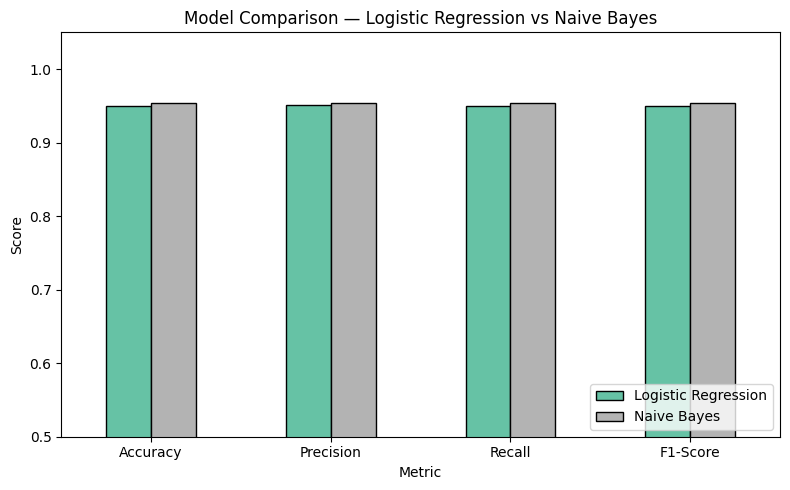

In [78]:
# ============================================================
# CELL 11: Compare both models side by side
# ============================================================

import pandas as pd

results = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Logistic Regression': [
        accuracy_score(y_test, lr_predictions),
        precision_score(y_test, lr_predictions, average='weighted', zero_division=0),
        recall_score(y_test, lr_predictions,    average='weighted', zero_division=0),
        f1_score(y_test, lr_predictions,        average='weighted', zero_division=0)
    ],
    'Naive Bayes': [
        accuracy_score(y_test, nb_predictions),
        precision_score(y_test, nb_predictions, average='weighted', zero_division=0),
        recall_score(y_test, nb_predictions,    average='weighted', zero_division=0),
        f1_score(y_test, nb_predictions,        average='weighted', zero_division=0)
    ]
})

results[['Logistic Regression', 'Naive Bayes']] = \
    results[['Logistic Regression', 'Naive Bayes']].round(4)

print(results.to_string(index=False))

# Bar chart comparison
results.set_index('Metric').plot(kind='bar', figsize=(8, 5), colormap='Set2', edgecolor='black')
plt.title('Model Comparison — Logistic Regression vs Naive Bayes')
plt.ylabel('Score')
plt.ylim(0.5, 1.05)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

🔮 Cell 12 — Test on Your Own Headlines

In [79]:
# ============================================================
# CELL 12: Predict on your own custom headlines
# ============================================================

import re, string

# Same cleaning function used during training
def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# ✏️ Change these headlines to anything you want!
my_headlines = [
    "Scientists discover new treatment for Alzheimer's disease",
    "You won't believe what this celebrity did next!",
    "Government announces new budget for 2025",
    "10 shocking things doctors don't want you to know",
    "Stock markets fall amid global economic concerns",
    "This one trick will make you rich overnight",
    "NASA confirms water found on the moon"
]

# Clean and vectorize
my_cleaned  = [clean_text(h) for h in my_headlines]
my_tfidf    = tfidf.transform(my_cleaned)

# Predict with Logistic Regression
my_preds    = lr_model.predict(my_tfidf)
my_probs    = lr_model.predict_proba(my_tfidf)  # confidence scores

print("=" * 65)
print(f"{'LABEL':<20} {'CONFIDENCE':>12}    HEADLINE")
print("=" * 65)
for headline, pred, prob in zip(my_headlines, my_preds, my_probs):
    label      = "🟡 CLICKBAIT" if pred == 1 else "🟢 NOT CLICKBAIT"
    confidence = f"{max(prob)*100:.1f}%"
    print(f"{label:<20} {confidence:>10}    {headline}")

LABEL                  CONFIDENCE    HEADLINE
🟢 NOT CLICKBAIT           85.4%    Scientists discover new treatment for Alzheimer's disease
🟡 CLICKBAIT               92.6%    You won't believe what this celebrity did next!
🟢 NOT CLICKBAIT           96.9%    Government announces new budget for 2025
🟡 CLICKBAIT               97.4%    10 shocking things doctors don't want you to know
🟢 NOT CLICKBAIT           94.8%    Stock markets fall amid global economic concerns
🟡 CLICKBAIT               81.0%    This one trick will make you rich overnight
🟢 NOT CLICKBAIT           92.7%    NASA confirms water found on the moon


📝 Cell 13 — Summary

In [80]:
# =========================
# CELL 13: Project summary
# =========================

summary = """
╔══════════════════════════════════════════════════════════════╗
║                     CLICKBAIT DETECTION                      ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  WHAT IS THE PROJECT?                                        ║
║  Binary text classification: given a news headline,          ║
║  predict whether it is clickbait (1) or not (0).             ║
║                                                              ║
║  PIPELINE STEPS:                                             ║
║  1. Download dataset via Kaggle API                          ║
║  2. Load into Pandas, auto-detect columns                    ║
║  3. Clean text — lowercase, remove punctuation/URLs          ║
║  4. TF-IDF vectorization — convert words to numbers          ║
║  5. Train Logistic Regression + Naive Bayes                  ║
║  6. Evaluate — Accuracy, Precision, Recall, F1, CM           ║
║                                                              ║
║  WHY LOGISTIC REGRESSION?                                    ║
║  • Clickbait detection is a LINEAR problem — certain         ║
║    words ("shocking", "you won't believe") strongly          ║
║    signal clickbait, and LR learns a weight per word         ║
║  • Fast, interpretable, and works great with TF-IDF          ║
║  • Outputs probability scores, not just yes/no               ║
║  • Handles high-dimensional sparse text data well            ║
║                                                              ║
║  KEY METRICS EXPLAINED:                                      ║
║  Accuracy  = correct predictions / total predictions         ║
║  Precision = true clickbait / all predicted as clickbait     ║
║  Recall    = true clickbait / all actual clickbait           ║
║  F1-Score  = harmonic mean of precision and recall           ║
║  Confusion Matrix = grid showing correct vs wrong            ║
║                                                              ║
╚══════════════════════════════════════════════════════════════╝
"""
print(summary)


╔══════════════════════════════════════════════════════════════╗
║                     CLICKBAIT DETECTION                      ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  WHAT IS THE PROJECT?                                        ║
║  Binary text classification: given a news headline,          ║
║  predict whether it is clickbait (1) or not (0).             ║
║                                                              ║
║  PIPELINE STEPS:                                             ║
║  1. Download dataset via Kaggle API                          ║
║  2. Load into Pandas, auto-detect columns                    ║
║  3. Clean text — lowercase, remove punctuation/URLs          ║
║  4. TF-IDF vectorization — convert words to numbers          ║
║  5. Train Logistic Regression + Naive Bayes                  ║
║  6. Evaluate — Accuracy, Precision, Recall, F1, CM           ║
║                       